**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# Data Preparation

In [13]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [14]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [15]:
df = encoder_labels_categoriques(df)

In [16]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [17]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [18]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.0,0,16.877316,46.000,50.8,26.0,...,4,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0
1,2,9.0,0.0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0
2,2,10.0,1.0,0,71.0,0,16.648696,56.500,75.6,26.5,...,1,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0
3,3,9.0,0.0,0,71.0,2,18.292347,56.000,81.6,26.0,...,1,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0
4,1,18.0,1.0,2,65.0,2,17.937682,60.485,77.0,26.0,...,1,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0


# Data Partitioning

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [20]:
X_train.shape

(5922, 83)

# Classification

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [22]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8967691095350669
F1-score [0.94533265 0.74228856 0.73298429 0.        ]
              precision    recall  f1-score   support

           0      0.949     0.941     0.945      1947
           1      0.724     0.761     0.742       490
           2      0.761     0.707     0.733        99
           3      0.000     0.000     0.000         2

    accuracy                          0.897      2538
   macro avg      0.609     0.602     0.605      2538
weighted avg      0.898     0.897     0.897      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

> The Decision Tree classifier achieves **89.7% overall accuracy**, driven by strong performance on the majority class (*None*, F1=0.945). However, the model **fails entirely on class 3** (*Severe*, F1=0.000), due to extreme class imbalance — only 2 test samples represent this category. To address this, we apply `class_weight='balanced'` and **SMOTE oversampling** on the training set only, ensuring the minority classes (*Moderate*, *Severe*) are better represented without introducing **data leakage** into the evaluation.

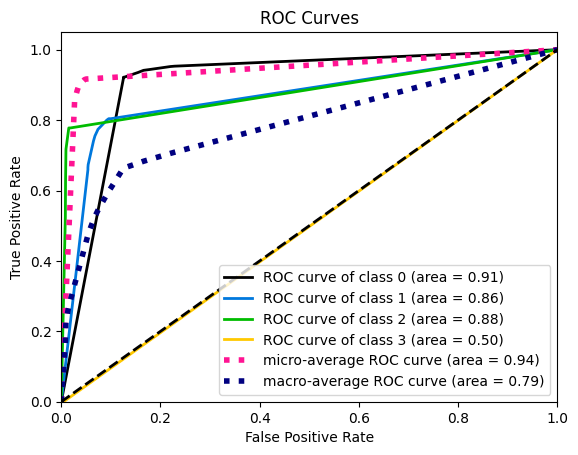

In [23]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

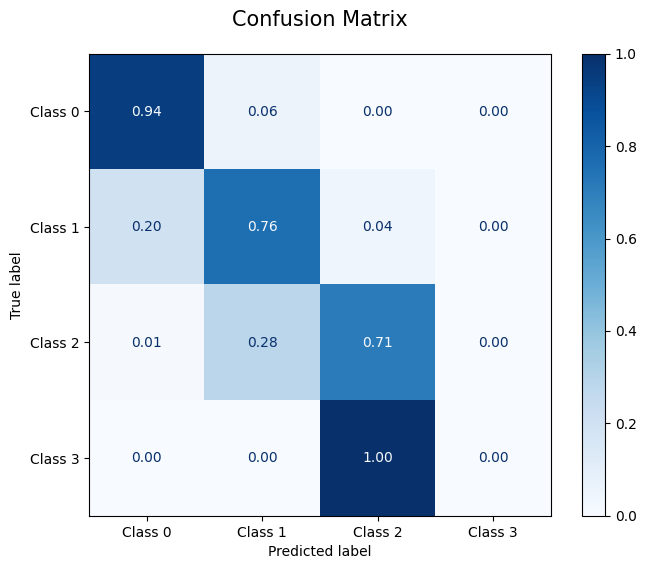

In [24]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Selection

## Variance Threshold

In [25]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([75,  3,  0,  0,  0,  0,  0,  1,  1,  1], dtype=int64),
 array([7.80615345e-02, 7.87318892e+02, 1.57455972e+03, 2.36180055e+03,
        3.14904138e+03, 3.93628221e+03, 4.72352304e+03, 5.51076387e+03,
        6.29800470e+03, 7.08524553e+03, 7.87248636e+03]))

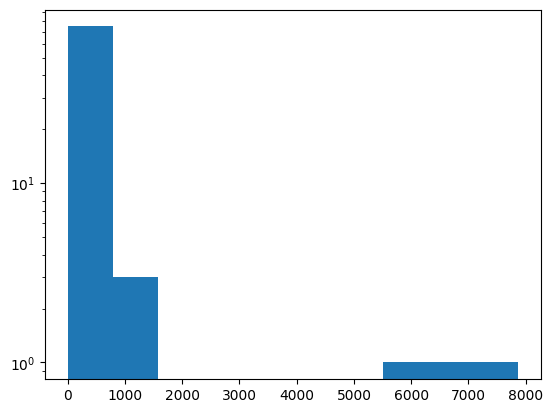

In [26]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [27]:
from sklearn.feature_selection import VarianceThreshold

In [28]:
(.8 * (1 - .8))

0.15999999999999998

In [29]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [30]:
X_train.shape

(5922, 83)

In [31]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8975571315996848
F1-score [0.9466082  0.74427861 0.71875    0.        ]
              precision    recall  f1-score   support

           0      0.951     0.942     0.947      1947
           1      0.726     0.763     0.744       490
           2      0.742     0.697     0.719        99
           3      0.000     0.000     0.000         2

    accuracy                          0.898      2538
   macro avg      0.605     0.601     0.602      2538
weighted avg      0.899     0.898     0.898      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

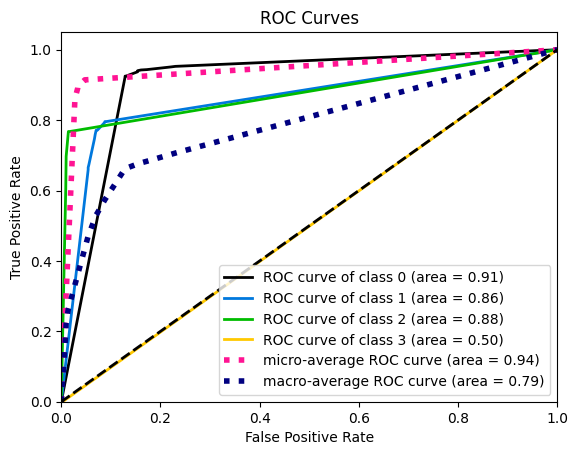

In [32]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

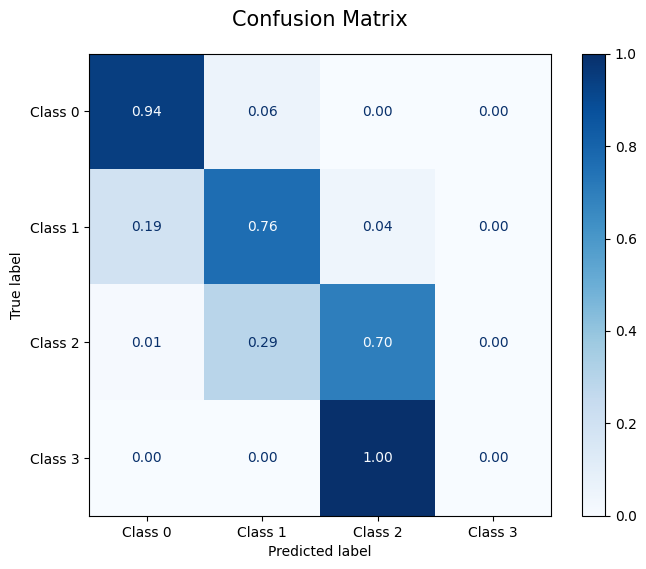

In [33]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Univariate Feature Selection

In [34]:
from sklearn.feature_selection import SelectKBest

In [35]:
sel = SelectKBest(k=40, score_func=f_classif)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 40)

In [36]:
sel.scores_

array([2.32789355e-02, 6.74553260e+01, 1.03270857e+01, 2.58175757e+00,
       1.01869741e+00, 5.37122807e+00, 3.81883772e+01, 5.62239269e+01,
       8.84086024e+01, 3.88005444e+01, 1.82866369e+01, 2.04240649e+00,
       2.93189544e+01, 1.25009220e+00, 6.96474530e-01, 2.36888065e-01,
       3.17709960e-01, 1.62160234e+00, 6.85372801e+01, 3.84502518e+00,
       2.37838414e+01, 9.77962419e+00, 1.86317015e+01, 6.51567376e+00,
       5.44141058e+01, 1.27928991e+01, 5.17892210e-01, 7.19354689e+00,
       5.25307160e+00, 1.01659346e+01, 6.50556959e+00, 9.35632866e+00,
       2.80732371e+00, 5.48759564e-01, 4.98979579e+00, 3.53356226e+01,
       3.03319591e+01, 4.23878809e+01, 1.61853299e+01, 8.08720502e+00,
       1.39092483e+01, 3.22488048e+01, 3.91980963e+01, 1.85361053e+01,
       3.31786288e+01, 1.63795025e+01, 1.85186495e+01, 1.66145213e+01,
       3.28183401e+01, 2.99637173e+01, 6.04984991e+00, 1.50618431e+00,
       4.62583307e+00, 2.85785599e+00, 8.98479459e+02, 1.09580704e+03,
      

In [37]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8963750985027581
F1-score [0.94665976 0.74708171 0.68478261 0.        ]
              precision    recall  f1-score   support

           0      0.955     0.939     0.947      1947
           1      0.714     0.784     0.747       490
           2      0.741     0.636     0.685        99
           3      0.000     0.000     0.000         2

    accuracy                          0.896      2538
   macro avg      0.602     0.590     0.595      2538
weighted avg      0.899     0.896     0.897      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

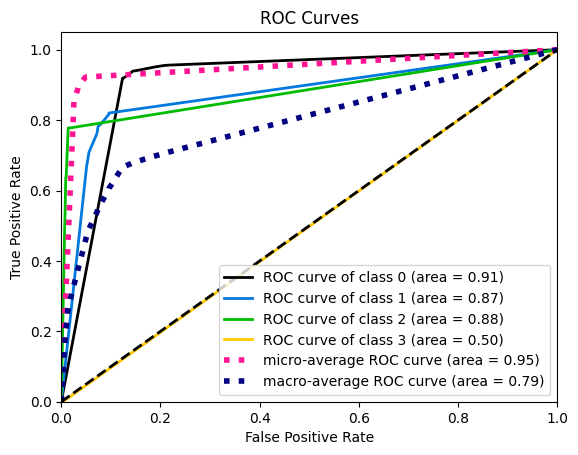

In [38]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

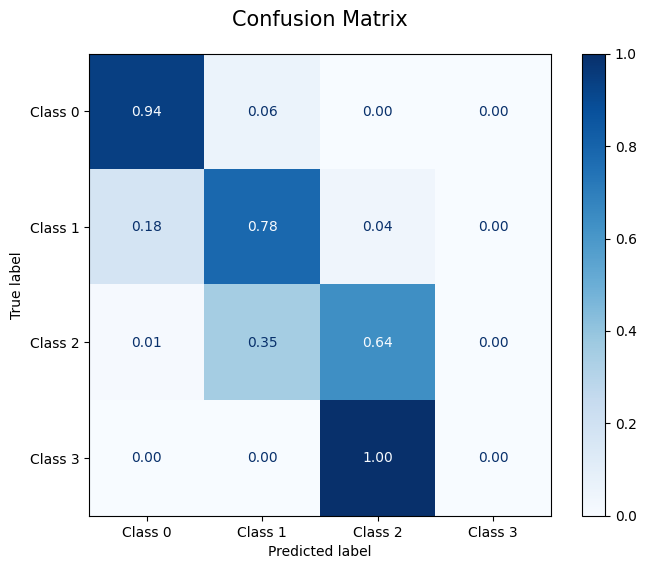

In [39]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Recursive Feature Elimination (RFE)

In [40]:
from sklearn.feature_selection import RFE

In [41]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [42]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8364854215918046
F1-score [0.91153359 0.57020364 0.60204082 0.        ]
              precision    recall  f1-score   support

           0      0.900     0.923     0.912      1947
           1      0.600     0.543     0.570       490
           2      0.608     0.596     0.602        99
           3      0.000     0.000     0.000         2

    accuracy                          0.836      2538
   macro avg      0.527     0.516     0.521      2538
weighted avg      0.830     0.836     0.833      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

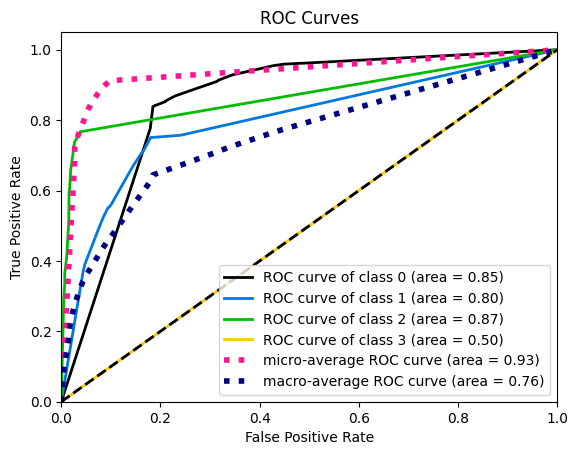

In [43]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

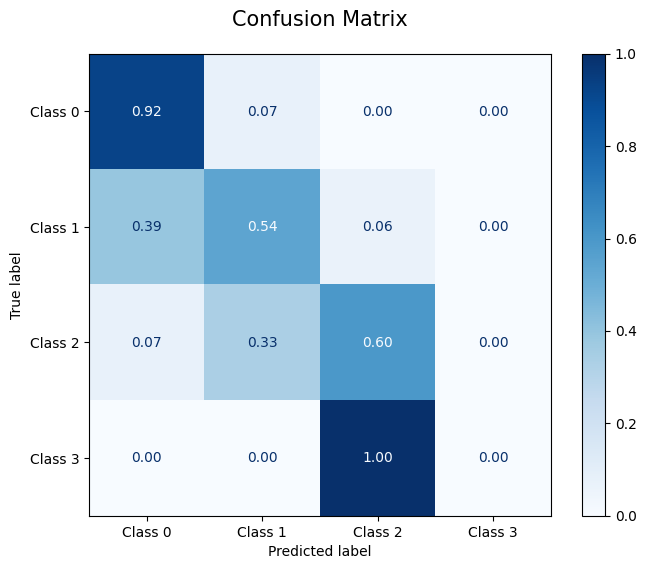

In [44]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [45]:
from sklearn.feature_selection import SelectFromModel

In [46]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 14)

In [47]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.9074074074074074
F1-score [0.95206357 0.76326531 0.74611399 0.        ]
              precision    recall  f1-score   support

           0      0.950     0.954     0.952      1947
           1      0.763     0.763     0.763       490
           2      0.766     0.727     0.746        99
           3      0.000     0.000     0.000         2

    accuracy                          0.907      2538
   macro avg      0.620     0.611     0.615      2538
weighted avg      0.906     0.907     0.907      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [48]:
# 1. Get the boolean mask (True for kept features, False for removed)
mask = sel.get_support()

# 2. Apply this mask to your ORIGINAL column names
# Replace 'df' with the name of your original DataFrame
original_feature_names = df.columns
real_feature_names = original_feature_names[mask]

# 3. Create the cleaned-up importance table
feature_importance_df = pd.DataFrame({
    'Feature': real_feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

           Feature  Importance
2   PCIAT-PCIAT_03    0.395902
9   PCIAT-PCIAT_13    0.082121
13  PCIAT-PCIAT_18    0.067715
11  PCIAT-PCIAT_15    0.067537
0      BIA-BIA_DEE    0.054921
10  PCIAT-PCIAT_14    0.051318
1   PCIAT-PCIAT_02    0.051245
12  PCIAT-PCIAT_17    0.050744
8   PCIAT-PCIAT_11    0.036373
6   PCIAT-PCIAT_09    0.032368
5   PCIAT-PCIAT_08    0.030472
7   PCIAT-PCIAT_10    0.026508
4   PCIAT-PCIAT_05    0.026488
3   PCIAT-PCIAT_04    0.026288


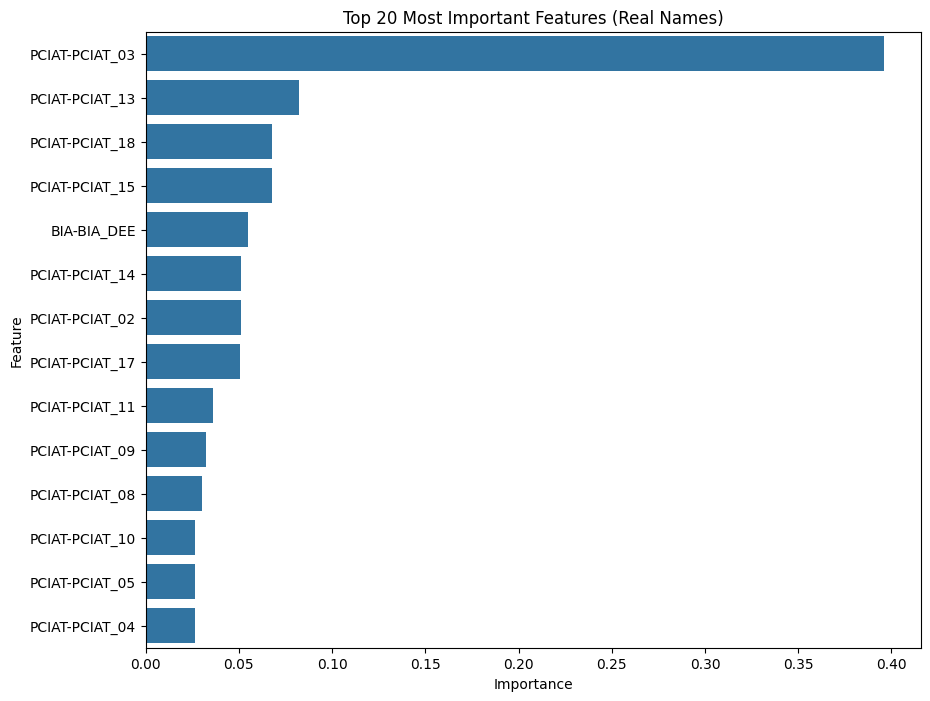

In [49]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Real Names)')
plt.show()

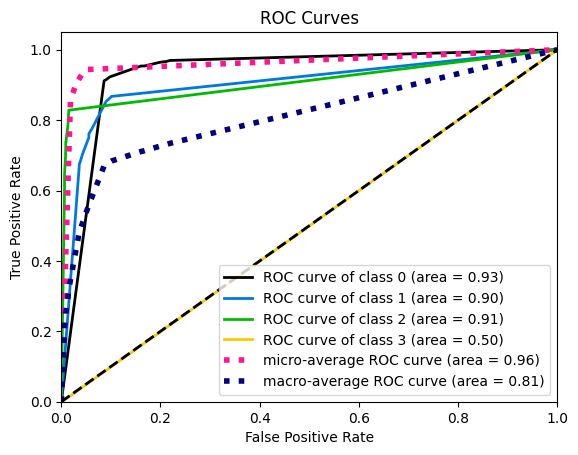

In [50]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

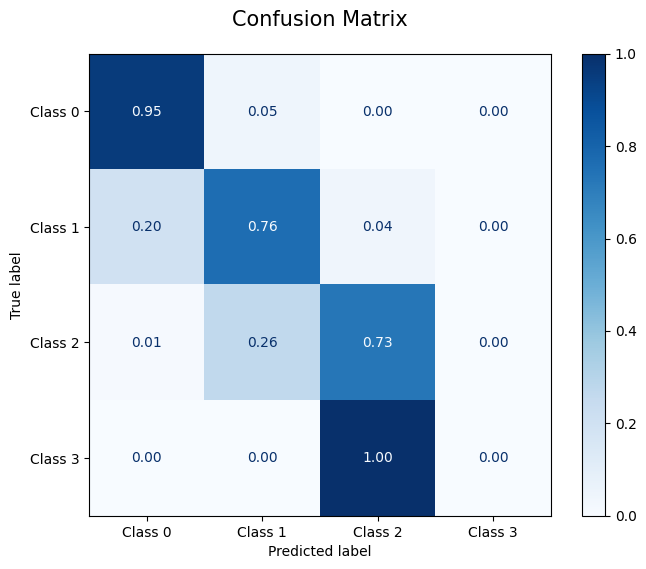

In [51]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Gradient Boosting

In [52]:
import xgboost as xgb

In [53]:
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 18)

In [54]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.9148936170212766
F1-score [0.95854657 0.78198567 0.70899471 0.        ]
              precision    recall  f1-score   support

           0      0.955     0.962     0.959      1947
           1      0.784     0.780     0.782       490
           2      0.744     0.677     0.709        99
           3      0.000     0.000     0.000         2

    accuracy                          0.915      2538
   macro avg      0.621     0.605     0.612      2538
weighted avg      0.913     0.915     0.914      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [55]:
# Access the fitted XGBoost model from the selector
trained_xgb = sel.estimator_

# Get importance (Gain represents the improvement in accuracy brought by a feature)
importance = trained_xgb.get_booster().get_score(importance_type='gain')

# Sort and print for better readability
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print(sorted_importance)

[('f56', 16.165143966674805), ('f68', 14.047248840332031), ('f71', 8.810685157775879), ('f70', 5.313416004180908), ('f66', 4.25838565826416), ('f58', 4.036343097686768), ('f55', 3.2275021076202393), ('f67', 2.8087048530578613), ('f61', 2.538882255554199), ('f62', 2.1871609687805176), ('f64', 1.9919241666793823), ('f63', 1.6834452152252197), ('f54', 1.682762622833252), ('f60', 1.6500436067581177), ('f65', 1.5620628595352173), ('f72', 1.3910858631134033), ('f57', 1.3188430070877075), ('f21', 1.2362561225891113), ('f59', 1.1509398221969604), ('f73', 1.0995914936065674), ('f69', 0.9336767792701721), ('f48', 0.9087485074996948), ('f47', 0.8275320529937744), ('f36', 0.7873886823654175), ('f33', 0.7572818398475647), ('f13', 0.6449946165084839), ('f40', 0.5945120453834534), ('f31', 0.5775174498558044), ('f34', 0.5713272094726562), ('f32', 0.5497105121612549), ('f42', 0.5461815595626831), ('f25', 0.5345045328140259), ('f78', 0.49722179770469666), ('f22', 0.48473653197288513), ('f1', 0.474514067

In [56]:
original_cols = df.columns 

# Apply the mask to get only the features the selector kept
selected_names = original_cols[sel.get_support()]

# Create the table
dt_importance = pd.DataFrame({
    'Feature': selected_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Decision Tree Importance ---")
print(dt_importance.head(20))

--- Decision Tree Importance ---
              Feature  Importance
3      PCIAT-PCIAT_03    0.391047
12     PCIAT-PCIAT_13    0.088516
14     PCIAT-PCIAT_15    0.068268
16     PCIAT-PCIAT_18    0.067925
15     PCIAT-PCIAT_17    0.050759
13     PCIAT-PCIAT_14    0.049291
2      PCIAT-PCIAT_02    0.040303
10     PCIAT-PCIAT_11    0.034063
8      PCIAT-PCIAT_09    0.030327
9      PCIAT-PCIAT_10    0.026912
4      PCIAT-PCIAT_04    0.024358
6      PCIAT-PCIAT_07    0.024282
7      PCIAT-PCIAT_08    0.023838
17     PCIAT-PCIAT_19    0.022930
1      PCIAT-PCIAT_01    0.021004
5      PCIAT-PCIAT_05    0.020454
11     PCIAT-PCIAT_12    0.014065
0   FGC-FGC_GSND_Zone    0.001659


In [57]:
importance_dict = trained_xgb.get_booster().get_score(importance_type='gain')

# 2. Map 'f#' to the column name at that index
# We use the original_cols list we defined above
real_names_dict = {}
for f_code, score in importance_dict.items():
    index = int(f_code.replace('f', ''))
    name = original_cols[index]
    real_names_dict[name] = score

# 3. Create the sorted table
xgb_importance = pd.DataFrame({
    'Feature': list(real_names_dict.keys()),
    'Gain': list(real_names_dict.values())
}).sort_values(by='Gain', ascending=False)

print("\n--- XGBoost Importance (Gain) ---")
print(xgb_importance.head(10))


--- XGBoost Importance (Gain) ---
           Feature       Gain
56  PCIAT-PCIAT_03  16.165144
68  PCIAT-PCIAT_15  14.047249
71  PCIAT-PCIAT_18   8.810685
70  PCIAT-PCIAT_17   5.313416
66  PCIAT-PCIAT_13   4.258386
58  PCIAT-PCIAT_05   4.036343
55  PCIAT-PCIAT_02   3.227502
67  PCIAT-PCIAT_14   2.808705
61  PCIAT-PCIAT_08   2.538882
62  PCIAT-PCIAT_09   2.187161


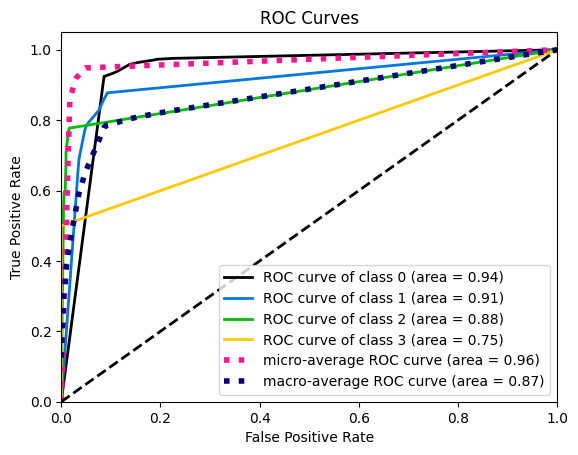

In [58]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

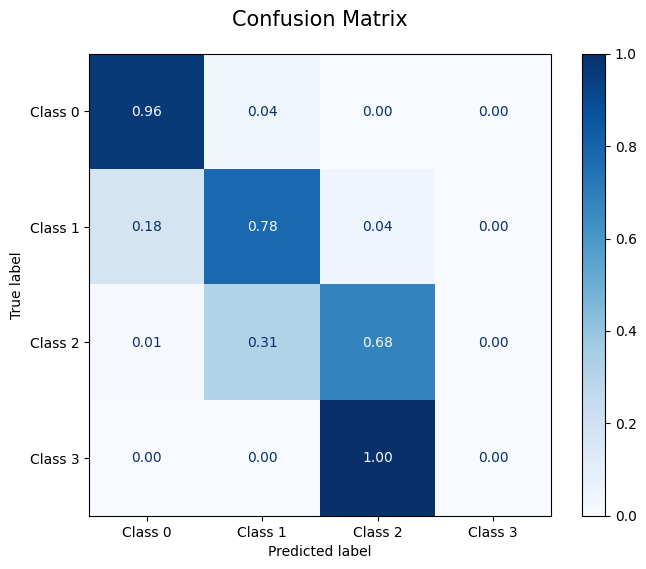

In [59]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Projection

## Principal Component Analysis

In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [63]:
X_train_pca.shape

(5922, 2)

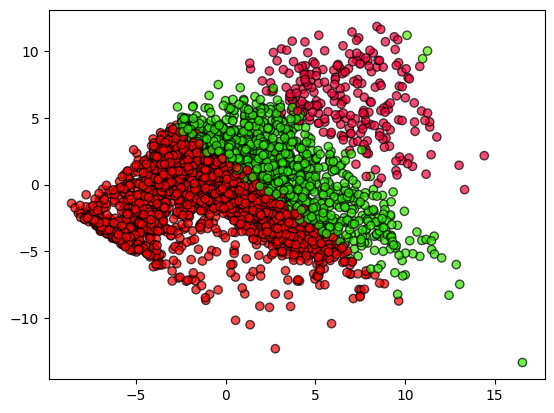

In [64]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [65]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9621749408983451
F1-score [0.97966538 0.90433031 0.91282051 0.66666667]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1947
           1       0.89      0.92      0.90       490
           2       0.93      0.90      0.91        99
           3       1.00      0.50      0.67         2

    accuracy                           0.96      2538
   macro avg       0.95      0.82      0.87      2538
weighted avg       0.96      0.96      0.96      2538



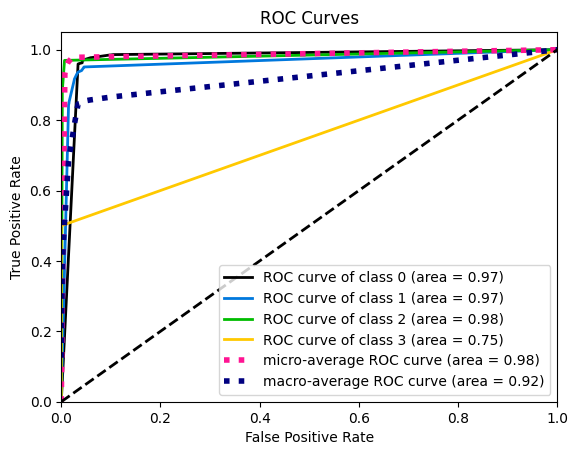

In [66]:
y_score = clf.predict_proba(X_test_pca)
plot_roc(y_test, y_score)
plt.show()

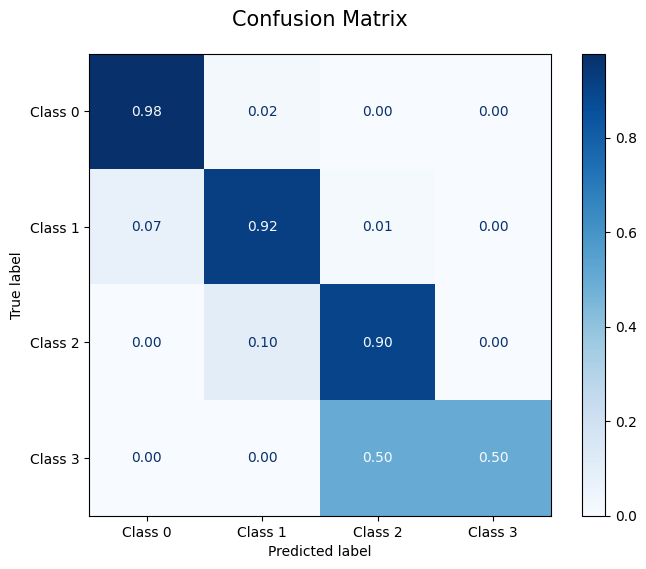

In [67]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

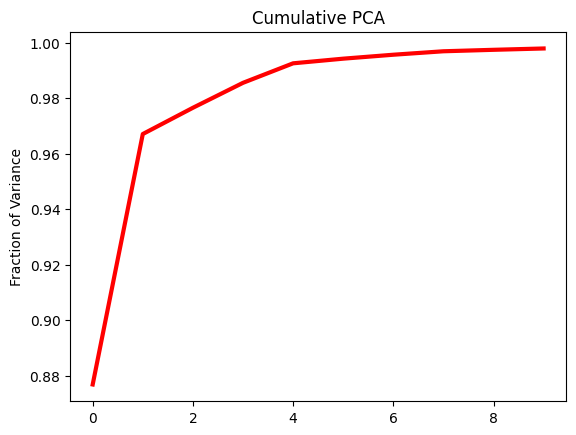

In [68]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

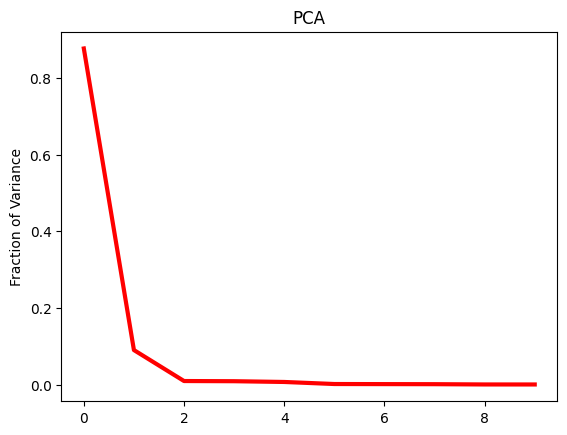

In [69]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [70]:
from sklearn import random_projection

In [71]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

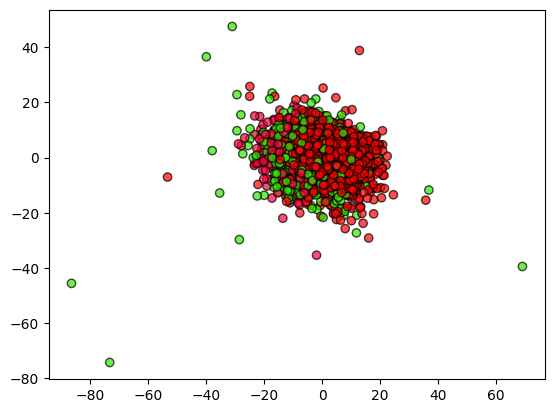

In [72]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [73]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7115839243498818
F1-score [0.83153402 0.28100988 0.24444444 0.        ]
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1947
           1       0.30      0.26      0.28       490
           2       0.27      0.22      0.24        99
           3       0.00      0.00      0.00         2

    accuracy                           0.71      2538
   macro avg       0.35      0.33      0.34      2538
weighted avg       0.69      0.71      0.70      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

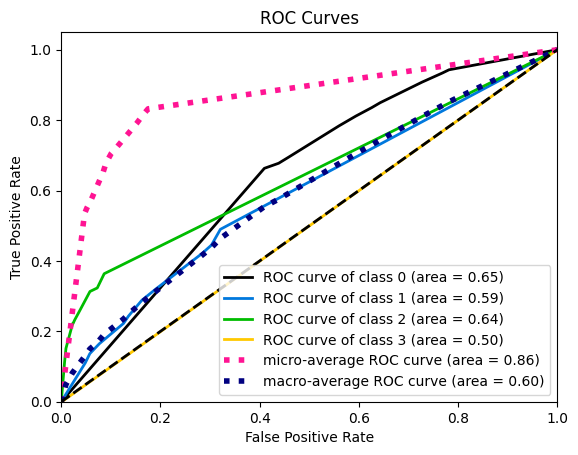

In [74]:
y_score = clf.predict_proba(X_test_rsp)
plot_roc(y_test, y_score)
plt.show()

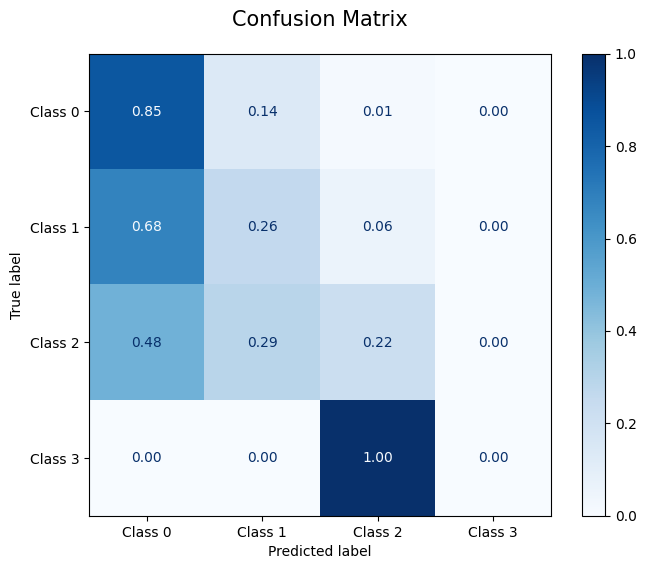

In [75]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Multi Dimensional Scaling

In [76]:
from sklearn.manifold import MDS

In [77]:
# Specifichiamo n_init e init per evitare i FutureWarning
mds = MDS(
    n_components=2, 
    n_init=4,           # Valore attuale di default (cambierà a 1 in futuro)
    init='random',      # Valore attuale di default (cambierà a 'classical_mds')
    normalized_stress='auto',
    random_state=42     # Sempre consigliato per rendere i risultati riproducibili
)

X_train_mds = mds.fit_transform(X_train_scaled)
print(X_train_mds.shape)

(5922, 2)


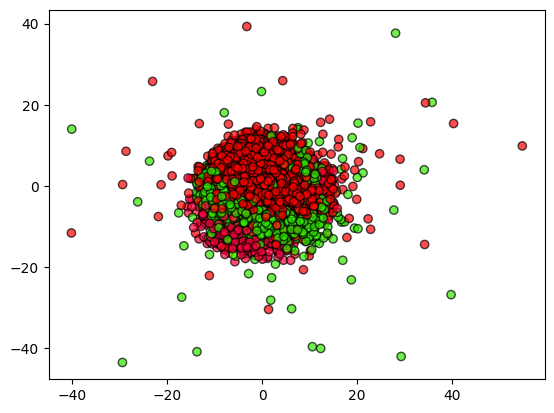

In [78]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [79]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.9381965552178319
F1-score [0.96450803 0.84894666 0.85209713 0.        ]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      4544
           1       0.87      0.83      0.85      1143
           2       0.87      0.83      0.85       232
           3       0.00      0.00      0.00         3

    accuracy                           0.94      5922
   macro avg       0.68      0.66      0.67      5922
weighted avg       0.94      0.94      0.94      5922



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## IsoMap

In [80]:
from sklearn.manifold import Isomap

In [81]:
iso = Isomap(n_components=2, n_neighbors=8) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

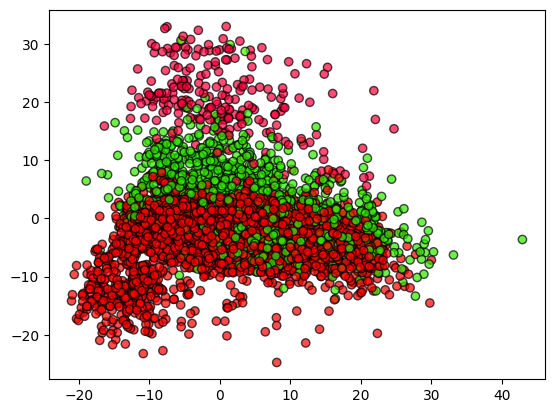

In [82]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [83]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8045705279747833
F1-score [0.88221827 0.48643006 0.81081081 0.        ]
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1947
           1       0.50      0.48      0.49       490
           2       0.87      0.76      0.81        99
           3       0.00      0.00      0.00         2

    accuracy                           0.80      2538
   macro avg       0.56      0.53      0.54      2538
weighted avg       0.80      0.80      0.80      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

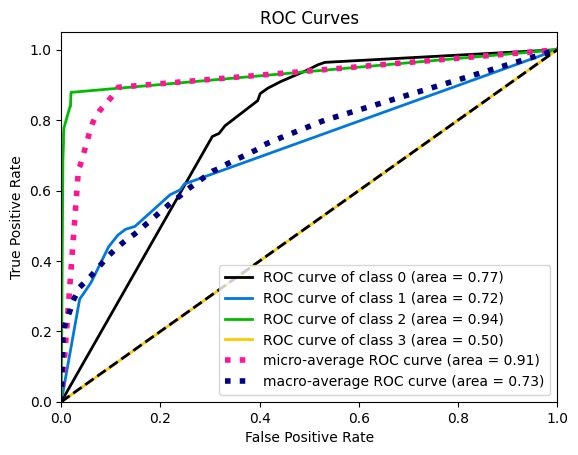

In [84]:
y_score = clf.predict_proba(X_test_iso)
plot_roc(y_test, y_score)
plt.show()

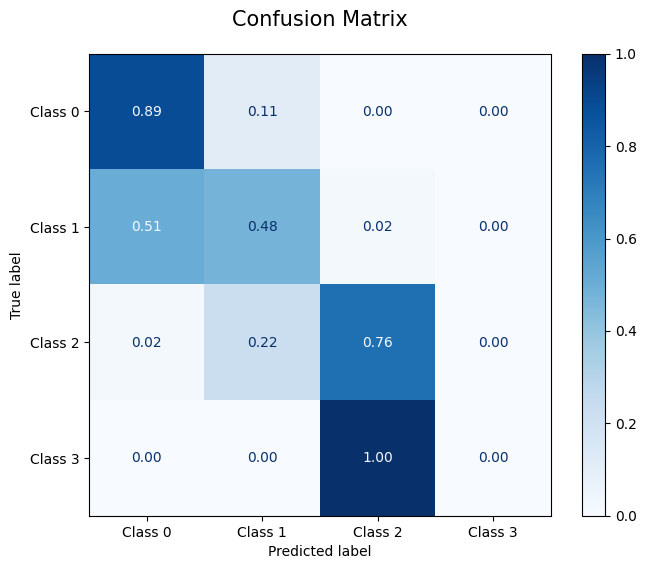

In [85]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## t-SNE

In [86]:
from sklearn.manifold import TSNE

In [87]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

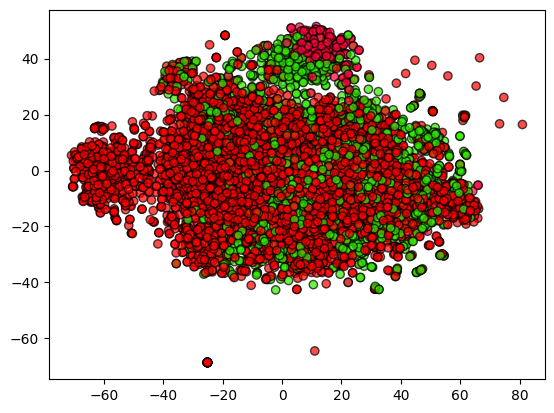

In [88]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [89]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.930935494765282
F1-score [0.95953757 0.81809955 0.90909091 0.        ]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4544
           1       0.85      0.79      0.82      1143
           2       0.91      0.91      0.91       232
           3       0.00      0.00      0.00         3

    accuracy                           0.93      5922
   macro avg       0.68      0.67      0.67      5922
weighted avg       0.93      0.93      0.93      5922



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave